In [1]:

import pandas as pd



In [2]:
import numpy as np

In [3]:
import json

In [4]:
from pathlib import Path

In [5]:
PROCESSED_DIR = Path("../data/processed")
K_FRAME_DIR = Path("../data/k_frames")

K_FRAME_DIR.mkdir(parents=True, exist_ok=True)

PROCESSED_METADATA_PATH = PROCESSED_DIR / "processed_metadata.csv"

In [6]:
metadata_df = pd.read_csv(PROCESSED_METADATA_PATH)

print(metadata_df.head())
print("Total frames:", len(metadata_df))
print("Total sites:", metadata_df["site_id"].nunique())

   split  site_id class_name  label  frame_index   frame_name  \
0  train        1     looted      1            0  2016_01.jpg   
1  train        1     looted      1            1  2016_02.jpg   
2  train        1     looted      1            2  2016_03.jpg   
3  train        1     looted      1            3  2016_04.jpg   
4  train        1     looted      1            4  2016_05.jpg   

                             raw_frame_path  \
0  ..\data\raw\DAFA_LS\looted\1\2016_01.jpg   
1  ..\data\raw\DAFA_LS\looted\1\2016_02.jpg   
2  ..\data\raw\DAFA_LS\looted\1\2016_03.jpg   
3  ..\data\raw\DAFA_LS\looted\1\2016_04.jpg   
4  ..\data\raw\DAFA_LS\looted\1\2016_05.jpg   

                            processed_frame_path  
0  ..\data\processed_images\looted\1\2016_01.jpg  
1  ..\data\processed_images\looted\1\2016_02.jpg  
2  ..\data\processed_images\looted\1\2016_03.jpg  
3  ..\data\processed_images\looted\1\2016_04.jpg  
4  ..\data\processed_images\looted\1\2016_05.jpg  
Total frames: 64114


In [7]:
print(metadata_df.columns)

Index(['split', 'site_id', 'class_name', 'label', 'frame_index', 'frame_name',
       'raw_frame_path', 'processed_frame_path'],
      dtype='str')


In [8]:
def get_site_frames(df, split, class_name, site_id):
    site_frames = df[
        (df["split"] == split) &
        (df["class_name"] == class_name) &
        (df["site_id"].astype(str) == str(site_id))
    ].copy()

    site_frames = site_frames.sort_values("frame_index")
    return site_frames

In [9]:
def select_k_frames(site_frames, k, strategy="recent", random_seed=42):
    """
    Select K frames from one site's time series.
    
    strategy:
    - recent: select last K frames
    - uniform: select K evenly spaced frames
    - random: select K random frames
    - early_late: select first and last frames for K=2
    """

    n = len(site_frames)

    if n < k:
        return None

    if strategy == "recent":
        selected = site_frames.tail(k)

    elif strategy == "uniform":
        indices = np.linspace(0, n - 1, k, dtype=int)
        selected = site_frames.iloc[indices]

    elif strategy == "random":
        selected = site_frames.sample(n=k, random_state=random_seed)
        selected = selected.sort_values("frame_index")

    elif strategy == "early_late":
        if k == 1:
            selected = site_frames.tail(1)
        elif k == 2:
            selected = site_frames.iloc[[0, n - 1]]
        else:
            indices = np.linspace(0, n - 1, k, dtype=int)
            selected = site_frames.iloc[indices]

    else:
        raise ValueError("Unknown strategy")

    return selected

In [10]:
def create_k_frame_dataset(metadata_df, k, strategy):
    rows = []

    site_groups = metadata_df.groupby(["split", "class_name", "site_id", "label"])

    for (split, class_name, site_id, label), site_frames in site_groups:
        site_frames = site_frames.sort_values("frame_index")

        selected = select_k_frames(site_frames, k=k, strategy=strategy)

        if selected is None:
            continue

        row = {
            "split": split,
            "site_id": site_id,
            "class_name": class_name,
            "label": label,
            "K": k,
            "strategy": strategy,
            "selected_frame_count": len(selected)
        }

        for i, (_, frame_row) in enumerate(selected.iterrows()):
            row[f"frame_{i+1}_index"] = frame_row["frame_index"]
            row[f"frame_{i+1}_name"] = frame_row["frame_name"]
            row[f"frame_{i+1}_path"] = frame_row["processed_frame_path"]

        rows.append(row)

    k_df = pd.DataFrame(rows)
    return k_df

In [11]:
K_VALUES = [1, 2, 3, 5, 8]

for k in K_VALUES:
    k_df = create_k_frame_dataset(
        metadata_df=metadata_df,
        k=k,
        strategy="recent"
    )

    output_path = K_FRAME_DIR / f"K{k}_recent.csv"
    k_df.to_csv(output_path, index=False)

    print(f"Saved: {output_path}")
    print(k_df.groupby(["split", "class_name"]).size())
    print()

Saved: ..\data\k_frames\K1_recent.csv
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
val_1  looted          9
       preserved       9
val_2  looted          9
       preserved       9
val_3  looted          9
       preserved       9
val_4  looted          9
       preserved       9
val_5  looted          9
       preserved       9
dtype: int64

Saved: ..\data\k_frames\K2_recent.csv
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
val_1  looted          9
       preserved       9
val_2  looted          9
       preserved       9
val_3  looted          9
       preserved       9
val_4  looted          9
       preserved       9
val_5  looted          9
       preserved       9
dtype: int64

Saved: ..\data\k_frames\K3_recent.csv
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
val_

In [12]:
for k in K_VALUES:
    k_df = create_k_frame_dataset(
        metadata_df=metadata_df,
        k=k,
        strategy="uniform"
    )

    output_path = K_FRAME_DIR / f"K{k}_uniform.csv"
    k_df.to_csv(output_path, index=False)

    print(f"Saved: {output_path}")
    print(k_df.groupby(["split", "class_name"]).size())
    print()

Saved: ..\data\k_frames\K1_uniform.csv
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
val_1  looted          9
       preserved       9
val_2  looted          9
       preserved       9
val_3  looted          9
       preserved       9
val_4  looted          9
       preserved       9
val_5  looted          9
       preserved       9
dtype: int64

Saved: ..\data\k_frames\K2_uniform.csv
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
val_1  looted          9
       preserved       9
val_2  looted          9
       preserved       9
val_3  looted          9
       preserved       9
val_4  looted          9
       preserved       9
val_5  looted          9
       preserved       9
dtype: int64

Saved: ..\data\k_frames\K3_uniform.csv
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
v

In [13]:
for k in [1, 2, 3, 5, 8]:
    k_df = create_k_frame_dataset(
        metadata_df=metadata_df,
        k=k,
        strategy="early_late"
    )

    output_path = K_FRAME_DIR / f"K{k}_early_late.csv"
    k_df.to_csv(output_path, index=False)

    print(f"Saved: {output_path}")
    print(k_df.groupby(["split", "class_name"]).size())
    print()

Saved: ..\data\k_frames\K1_early_late.csv
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
val_1  looted          9
       preserved       9
val_2  looted          9
       preserved       9
val_3  looted          9
       preserved       9
val_4  looted          9
       preserved       9
val_5  looted          9
       preserved       9
dtype: int64

Saved: ..\data\k_frames\K2_early_late.csv
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
val_1  looted          9
       preserved       9
val_2  looted          9
       preserved       9
val_3  looted          9
       preserved       9
val_4  looted          9
       preserved       9
val_5  looted          9
       preserved       9
dtype: int64

Saved: ..\data\k_frames\K3_early_late.csv
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved 

In [14]:
for k in K_VALUES:
    k_df = create_k_frame_dataset(
        metadata_df=metadata_df,
        k=k,
        strategy="random"
    )

    output_path = K_FRAME_DIR / f"K{k}_random.csv"
    k_df.to_csv(output_path, index=False)

    print(f"Saved: {output_path}")
    print(k_df.groupby(["split", "class_name"]).size())
    print()

Saved: ..\data\k_frames\K1_random.csv
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
val_1  looted          9
       preserved       9
val_2  looted          9
       preserved       9
val_3  looted          9
       preserved       9
val_4  looted          9
       preserved       9
val_5  looted          9
       preserved       9
dtype: int64

Saved: ..\data\k_frames\K2_random.csv
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
val_1  looted          9
       preserved       9
val_2  looted          9
       preserved       9
val_3  looted          9
       preserved       9
val_4  looted          9
       preserved       9
val_5  looted          9
       preserved       9
dtype: int64

Saved: ..\data\k_frames\K3_random.csv
split  class_name
test   looted         26
       preserved      35
train  looted         64
       preserved     460
val_

In [15]:
k8_recent = pd.read_csv(K_FRAME_DIR / "K8_recent.csv")

print(k8_recent.head())
print(k8_recent.columns)
print(k8_recent.groupby(["split", "class_name"]).size())

  split  site_id class_name  label  K strategy  selected_frame_count  \
0  test       26     looted      1  8   recent                     8   
1  test       27     looted      1  8   recent                     8   
2  test       29     looted      1  8   recent                     8   
3  test       30     looted      1  8   recent                     8   
4  test       31     looted      1  8   recent                     8   

   frame_1_index frame_1_name                                    frame_1_path  \
0             88  2023_06.jpg  ..\data\processed_images\looted\26\2023_06.jpg   
1             87  2023_06.jpg  ..\data\processed_images\looted\27\2023_06.jpg   
2             88  2023_06.jpg  ..\data\processed_images\looted\29\2023_06.jpg   
3             87  2023_06.jpg  ..\data\processed_images\looted\30\2023_06.jpg   
4             87  2023_06.jpg  ..\data\processed_images\looted\31\2023_06.jpg   

   ...                                    frame_5_path frame_6_index  \
0  ...  

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

def show_k_sample(k_df, row_index=0):
    row = k_df.iloc[row_index]
    k = int(row["K"])

    plt.figure(figsize=(16, 4))

    for i in range(1, k + 1):
        img_path = row[f"frame_{i}_path"]
        img = Image.open(img_path).convert("RGB")

        plt.subplot(1, k, i)
        plt.imshow(img)
        plt.title(row[f"frame_{i}_name"][:10])
        plt.axis("off")

    plt.suptitle(
        f'{row["class_name"]} | site {row["site_id"]} | K={k} | {row["strategy"]}'
    )
    plt.show()

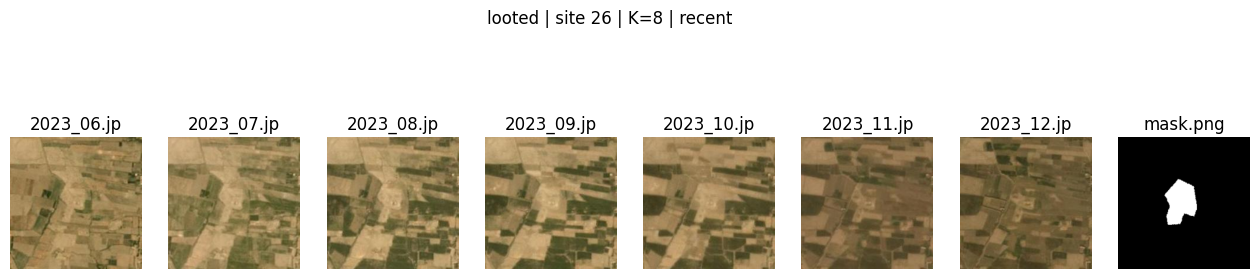

In [25]:
show_k_sample(k8_recent, row_index=0)

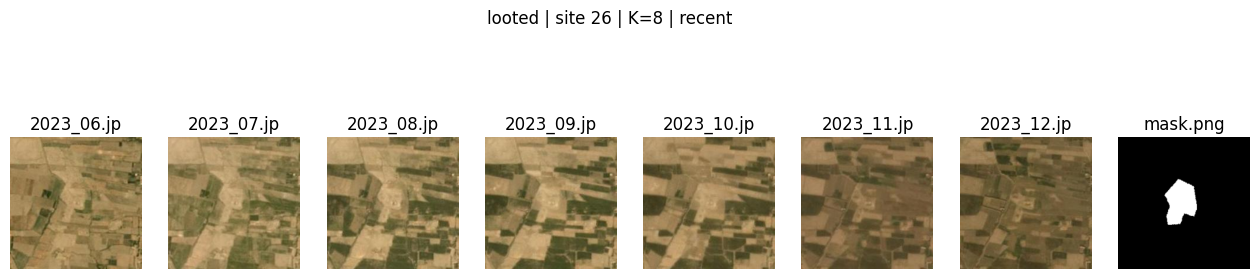

In [18]:
looted_row_index = k8_recent[k8_recent["label"] == 1].index[0]
show_k_sample(k8_recent, row_index=looted_row_index)

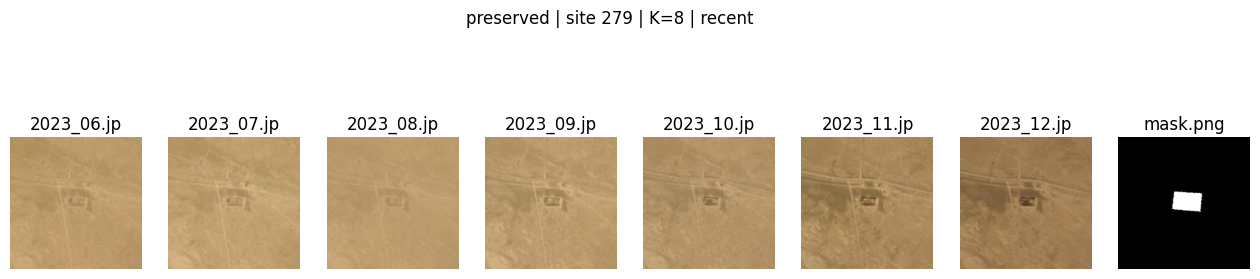

In [19]:
preserved_row_index = k8_recent[k8_recent["label"] == 0].index[0]
show_k_sample(k8_recent, row_index=preserved_row_index)

In [26]:
summary_rows = []

for csv_file in K_FRAME_DIR.glob("K*.csv"):
    df = pd.read_csv(csv_file)

    summary_rows.append({
        "file": csv_file.name,
        "K": df["K"].iloc[0],
        "strategy": df["strategy"].iloc[0],
        "total_sites": len(df),
        "train_sites": len(df[df["split"] == "train"]),
        "test_sites": len(df[df["split"] == "test"]),
        "looted_sites": len(df[df["label"] == 1]),
        "preserved_sites": len(df[df["label"] == 0])
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(["K", "strategy"])

summary_df.to_csv(K_FRAME_DIR / "k_frame_summary.csv", index=False)

summary_df

,file,K,strategy,total_sites,train_sites,test_sites,looted_sites,preserved_sites
0,K1_early_late.csv,1,early_late,675,524,61,135,540
1,K1_random.csv,1,random,675,524,61,135,540
2,K1_recent.csv,1,recent,675,524,61,135,540
3,K1_uniform.csv,1,uniform,675,524,61,135,540
4,K2_early_late.csv,2,early_late,675,524,61,135,540
5,K2_random.csv,2,random,675,524,61,135,540
6,K2_recent.csv,2,recent,675,524,61,135,540
7,K2_uniform.csv,2,uniform,675,524,61,135,540
8,K3_early_late.csv,3,early_late,675,524,61,135,540
9,K3_random.csv,3,random,675,524,61,135,540
